In [ ]:
# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Unlock SQL and Python interoperability for BigQuery with %%bqsql magic

In this tutorial, you will learn how to seamlessly chain data processing across
SQL and Python code cells using `%%bqsql` IPython magic and BigQuery DataFrames
(BigFrames). This interoperability is now available to all Jupyter users,
whether you're in Colab, JupyterLab, or VS Code. 

While we begin by loading a local Excel dataset into a local Pandas DataFrame,
the main focus is on how you can transition between Pandas' Python-centric API
and BigQuery's SQL-centric engine. This hybrid workflow combines the best of
both worlds: the expressive power of SQL for complex transformations and the
versatile Python ecosystem for visualization and further analysis.

Thanks to open-source packages like Jupyter, Pandas, BigFrames, and the
[BigQuery sandbox](https://docs.cloud.google.com/bigquery/docs/sandbox), you can
follow all steps in this guide for free\* and without a credit card.

_\*See the [BigQuery sandbox](https://docs.cloud.google.com/bigquery/docs/sandbox) documentation for limitations._

## The %%bqsql Magic

Last year, Google introduced [SQL cells in Colab Enterprise
notebooks](https://docs.cloud.google.com/colab/docs/sql-cells). Now, with the
[%%bqsql cell
magics](https://dataframes.bigquery.dev/notebooks/getting_started/magics.html)
in BigQuery DataFrames, this same powerful interoperability is available to all
Jupyter users, whether you're in Colab, JupyterLab, or VS Code. These magics
allow you to write SQL queries that run directly on local pandas DataFrames,
BigFrames DataFrames, or BigQuery tables.


## Getting Started

To get started,

1. Enable the [BigQuery
   sandbox](https://docs.cloud.google.com/bigquery/docs/sandbox). Make note of your
   Google Cloud project ID.

2. Set up a local Python development environment (see: [Setting up a Python
   development environment](https://docs.cloud.google.com/python/docs/setup)) for
   Google Cloud.

3. Create and activate a venv to isolate Python dependencies.
   On Linux or macOS, use these commands (update to your preferred Python
   version):

   ```
   python3.12 -m venv ~/venv
   . ~/venv/bin/activate
   ```

4. Install the Jupyter, bigframes, and python-calamine packages:

   ```
   pip install --upgrade jupyterlab bigframes python-calamine
   ```

5. Start Jupyter Lab.

   ```
   jupyter lab
   ```

6. Open a web browser to the URL listed in the output. It will be something like
   `http://localhost:8888/lab?token=somesupersecretvaluehere`.

7. Create a new notebook using the Jupyter Lab UI.


In [ ]:
%pip install python-calamine pandas bigframes

## Accessing the Dataset

In this tutorial, you'll analyze the [USDA wheat
data](https://www.ers.usda.gov/data-products/wheat-data). Use the standard
`requests` package to download the data to a temporary file, mimicking a typical
local data analysis workflow.


In [1]:

import tempfile

import requests

url = "https://www.ers.usda.gov/media/5706/wheat-data-all-years.xlsx?v=52690"

tmp = tempfile.NamedTemporaryFile(delete=True)

with requests.get(url, stream=True) as r:
    r.raise_for_status()
    for chunk in r.iter_content(chunk_size=8192):
        tmp.write(chunk)

tmp.flush()
tmp.seek(0)

0

Use the `pyarrow` `dtype_backend` when preparing local Pandas data for SQL
processing. This ensures more consistent handling of NULL values and seamless
schema mapping when you hand off the data to the BigQuery SQL engine. For this
example, read the 'Table05' sheet, which contains annual wheat supply and
disappearance data:


In [2]:

import pandas as pd

df = pd.read_excel(
    tmp,
    sheet_name="Table05",
    dtype_backend="pyarrow",
    engine="calamine",
    header=1,  # Skip the first row.
)
tmp.close()
df

,Marketing year 1/,Time period,Beginning stocks,Production,Imports 2/,Total supply 3/,Food use,Seed use,Feed and residual use,Total domestic use 3/,Exports 2/,Total disappearance 3/,Ending stocks
0,1950/51,MY Jun-May,496.0,1019.0,11.0,1526.0,580.0,--,109.0,689.0,345.0,1034.0,492.0
1,1951/52,MY Jun-May,492.0,988.0,30.0,1510.0,585.0,--,110.0,695.0,485.0,1180.0,330.0
2,1952/53,MY Jun-May,330.0,1306.0,24.0,1660.0,578.0,--,78.0,656.0,332.0,988.0,672.0
3,1953/54,MY Jun-May,672.0,1173.0,6.0,1851.0,556.0,--,87.0,643.0,214.0,857.0,994.0
4,1954/55,MY Jun-May,994.0,984.0,3.0,1981.0,552.0,--,53.0,605.0,267.0,872.0,1109.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,1/ June–May. Latest data may be preliminary or...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
282,2/ Includes flour and selected other products ...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
283,3/ Totals may not add due to rounding.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
284,"Source: USDA, Economic Research Service, based...",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## Preparing the data

Before querying the local DataFrame with SQL, ensure that the column names are
SQL-friendly. BigQuery supports [flexible column
names](https://docs.cloud.google.com/bigquery/docs/schemas#flexible-column-names),
allowing most unicode characters, but special characters like "/" and "\" must
be removed or replaced.


In [3]:
df.columns = [name.replace("/", "") for name in df.columns]
df

,Marketing year 1,Time period,Beginning stocks,Production,Imports 2,Total supply 3,Food use,Seed use,Feed and residual use,Total domestic use 3,Exports 2,Total disappearance 3,Ending stocks
0,1950/51,MY Jun-May,496.0,1019.0,11.0,1526.0,580.0,--,109.0,689.0,345.0,1034.0,492.0
1,1951/52,MY Jun-May,492.0,988.0,30.0,1510.0,585.0,--,110.0,695.0,485.0,1180.0,330.0
2,1952/53,MY Jun-May,330.0,1306.0,24.0,1660.0,578.0,--,78.0,656.0,332.0,988.0,672.0
3,1953/54,MY Jun-May,672.0,1173.0,6.0,1851.0,556.0,--,87.0,643.0,214.0,857.0,994.0
4,1954/55,MY Jun-May,994.0,984.0,3.0,1981.0,552.0,--,53.0,605.0,267.0,872.0,1109.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,1/ June–May. Latest data may be preliminary or...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
282,2/ Includes flour and selected other products ...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
283,3/ Totals may not add due to rounding.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
284,"Source: USDA, Economic Research Service, based...",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## Filtering with Pandas

Perform a basic filter using standard Python/Pandas syntax to remove rows with missing data. This represents the initial Python-only stage of a processing chain.


In [4]:
full_rows = df[~df['Beginning stocks'].isna()]
full_rows

,Marketing year 1,Time period,Beginning stocks,Production,Imports 2,Total supply 3,Food use,Seed use,Feed and residual use,Total domestic use 3,Exports 2,Total disappearance 3,Ending stocks
0,1950/51,MY Jun-May,496.0,1019.0,11.0,1526.0,580.0,--,109.0,689.0,345.0,1034.0,492.0
1,1951/52,MY Jun-May,492.0,988.0,30.0,1510.0,585.0,--,110.0,695.0,485.0,1180.0,330.0
2,1952/53,MY Jun-May,330.0,1306.0,24.0,1660.0,578.0,--,78.0,656.0,332.0,988.0,672.0
3,1953/54,MY Jun-May,672.0,1173.0,6.0,1851.0,556.0,--,87.0,643.0,214.0,857.0,994.0
4,1954/55,MY Jun-May,994.0,984.0,3.0,1981.0,552.0,--,53.0,605.0,267.0,872.0,1109.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,2025/26,MY Jun-May,854.734,1984.537,125.0,2964.271,960.0,59.7,100.0,1119.7,910.0,2029.7,934.571
276,2025/26,Q1 Jun-Aug,854.734,1984.537,30.593,2869.864,241.091,2.653,239.522,483.266,252.58,735.846,2134.018
277,2025/26,Q2 Sep-Nov,2134.018,0.0,30.078,2164.096,245.58,39.658,-54.047,231.191,255.802,486.993,1677.103
278,2025/26,Q3 Dec-Feb,1677.103,0.0,32.363,1709.466,230.975,1.75,-24.747,207.978,201.291,409.269,1300.197


## Interoperate with SQL using the BigQuery SQL magics (%%bqsql)

The BigQuery DataFrames library provides the `%%bqsql` magic, which acts as the bridge between your Python and SQL environments. It allows the BigQuery query engine to directly reference and query your local Pandas DataFrames (by implicitly uploading them as temporary tables) as well as actual BigQuery tables and external tables in GCS (Parquet, Iceberg, CSV).

To enable this integration in your notebook, load the `bigframes` extension. This is already completed in BigQuery Studio, Colab Enterprise, and Colab notebooks. For other environments, such as VS Code and Jupyter Lab, run the following cell:


In [5]:
%load_ext bigframes


To ensure the correct Google Cloud project is billed for query usage, including free tier usage, configure the project ID used by the magics. Even in the free sandbox tier, a project ID is required to allocate query resources. If you don't set it explicitly, BigFrames will try to discover it from your environment (e.g., your Application Default Credentials).


In [8]:
import bigframes.pandas as bpd

PROJECT_ID = "" # @param {type:"string"}
bpd.options.bigquery.project = PROJECT_ID


### Querying Local Pandas DataFrames with SQL

With the project configured, you can now run SQL queries directly against your local Pandas DataFrame (`full_rows`) as if it were a table in BigQuery. Simply reference the variable name inside braces `{full_rows}` in your SQL query.


In [9]:
%%bqsql
SELECT * FROM {full_rows}


,Marketing year 1,Time period,Beginning stocks,Production,Imports 2,Total supply 3,Food use,Seed use,Feed and residual use,Total domestic use 3,Exports 2,Total disappearance 3,Ending stocks
0,1980/81,Q2 Sep-Nov,2714.0,0.0,0.6,2714.6,162.1,76,4.865,242.965,379.335,622.3,2092.3
1,1987/88,Q2 Sep-Nov,2976.462,0.0,4.525,2980.987,193.048,58,-79.082,171.966,308.453,480.419,2500.568
2,2014/15,Q2 Sep-Nov,1907.22,0.0,34.551,1941.771,248.187,48.802,-92.585,204.404,207.737,412.141,1529.63
3,1976/77,Q2 Sep-Nov,2385.2,0.0,0.5,2385.7,153.0,64,-2.795,214.205,277.295,491.5,1894.2
4,1994/95,Q2 Sep-Nov,2069.494,0.0,21.423,2090.917,229.297,60.954,-28.64,261.611,338.202,599.813,1491.104
5,2002/03,Q2 Sep-Nov,1748.987,0.0,23.087,1772.074,237.754,54.599,-74.678,217.675,234.53,452.205,1319.869
6,2007/08,Q2 Sep-Nov,1716.927,0.0,21.486,1738.413,245.026,59.915,-119.882,185.059,421.416,606.475,1131.938
7,2025/26,Q2 Sep-Nov,2134.018,0.0,30.078,2164.096,245.58,39.658,-54.047,231.191,255.802,486.993,1677.103
8,1995/96,Q2 Sep-Nov,1881.099,0.0,16.252,1897.351,232.151,64.356,-98.182,198.325,360.759,559.084,1338.267
9,2001/02,Q2 Sep-Nov,2155.814,0.0,29.04,2184.854,245.088,51.601,-23.073,273.616,287.783,561.399,1623.455


You should see the results from full_rows.


## Chaining SQL and Python: Saving SQL Results

The true power of the `%%bqsql` magic lies in chaining. By providing a destination variable name as an argument to `%%bqsql` (e.g., `%%bqsql destination_var`), the query result is saved as a BigQuery DataFrame (a.k.a. BigFrames DataFrame) to that variable. 

This DataFrame lives on the BigQuery engine but behaves like a Pandas DataFrame in Python. You can immediately use it in subsequent Python cells, or reference it again in another SQL cell. This allows you to build a multi-step, hybrid processing pipeline.

Filter the data to only yearly entries using SQL, and save the result into a new BigFrames DataFrame named `yearly`:


In [10]:
%%bqsql yearly
SELECT *
FROM {full_rows}
WHERE STARTS_WITH(`Time period`, 'MY')


,Marketing year 1,Time period,Beginning stocks,Production,Imports 2,Total supply 3,Food use,Seed use,Feed and residual use,Total domestic use 3,Exports 2,Total disappearance 3,Ending stocks
0,1955/56,MY Jun-May,1109.0,937.0,10.0,2056.0,553.0,--,51.0,604.0,322.0,926.0,1130.0
1,1957/58,MY Jun-May,1004.0,956.0,10.0,1970.0,547.0,--,43.0,590.0,418.0,1008.0,962.0
2,1954/55,MY Jun-May,994.0,984.0,3.0,1981.0,552.0,--,53.0,605.0,267.0,872.0,1109.0
3,1951/52,MY Jun-May,492.0,988.0,30.0,1510.0,585.0,--,110.0,695.0,485.0,1180.0,330.0
4,1956/57,MY Jun-May,1130.0,1005.0,8.0,2143.0,541.0,--,57.0,598.0,541.0,1139.0,1004.0
5,1950/51,MY Jun-May,496.0,1019.0,11.0,1526.0,580.0,--,109.0,689.0,345.0,1034.0,492.0
6,1962/63,MY Jun-May,1420.6,1092.0,5.3,2517.9,502.7,61.4,34.7,598.8,649.4,1248.2,1269.7
7,1959/60,MY Jun-May,1368.0,1118.0,7.0,2493.0,558.0,--,49.0,607.0,502.0,1109.0,1384.0
8,1963/64,MY Jun-May,1269.7,1146.8,4.0,2420.5,487.9,64.9,28.6,581.4,845.6,1427.0,993.5
9,1953/54,MY Jun-May,672.0,1173.0,6.0,1851.0,556.0,--,87.0,643.0,214.0,857.0,994.0


### Chaining Step 2: Complex SQL Transformation on the BigFrames DataFrame

Now, you can chain another SQL operation. Reference the `yearly` BigFrames DataFrame that you just created, extract the year using SQL regular expressions, cast it to a timestamp, and save the results into a new BigFrames DataFrame named `timeseries`.

Notice how you are building a chain: Local Pandas -> [SQL filter] -> BigFrames `yearly` -> [SQL transform] -> BigFrames `timeseries`.


In [11]:
%%bqsql timeseries
SELECT
  * EXCEPT (`Marketing year 1`),
  TIMESTAMP(CONCAT(
    REGEXP_EXTRACT(`Marketing year 1`, r'([0-9]+)\/'),
    '-01-01')) AS `year`
FROM {yearly}


,Time period,Beginning stocks,Production,Imports 2,Total supply 3,Food use,Seed use,Feed and residual use,Total domestic use 3,Exports 2,Total disappearance 3,Ending stocks,year
0,MY Jun-May,1004.0,956.0,10.0,1970.0,547.0,--,43.0,590.0,418.0,1008.0,962.0,1957-01-01 00:00:00+00:00
1,MY Jun-May,672.0,1173.0,6.0,1851.0,556.0,--,87.0,643.0,214.0,857.0,994.0,1953-01-01 00:00:00+00:00
2,MY Jun-May,496.0,1019.0,11.0,1526.0,580.0,--,109.0,689.0,345.0,1034.0,492.0,1950-01-01 00:00:00+00:00
3,MY Jun-May,330.0,1306.0,24.0,1660.0,578.0,--,78.0,656.0,332.0,988.0,672.0,1952-01-01 00:00:00+00:00
4,MY Jun-May,962.0,1457.0,8.0,2427.0,561.0,--,48.0,609.0,450.0,1059.0,1368.0,1958-01-01 00:00:00+00:00
5,MY Jun-May,994.0,984.0,3.0,1981.0,552.0,--,53.0,605.0,267.0,872.0,1109.0,1954-01-01 00:00:00+00:00
6,MY Jun-May,492.0,988.0,30.0,1510.0,585.0,--,110.0,695.0,485.0,1180.0,330.0,1951-01-01 00:00:00+00:00
7,MY Jun-May,1130.0,1005.0,8.0,2143.0,541.0,--,57.0,598.0,541.0,1139.0,1004.0,1956-01-01 00:00:00+00:00
8,MY Jun-May,1109.0,937.0,10.0,2056.0,553.0,--,51.0,604.0,322.0,926.0,1130.0,1955-01-01 00:00:00+00:00
9,MY Jun-May,1368.0,1118.0,7.0,2493.0,558.0,--,49.0,607.0,502.0,1109.0,1384.0,1959-01-01 00:00:00+00:00


## Chaining Back to Python: Visualizing BigFrames Data

Now that you've completed some SQL transformations, you can chain back to Python for visualization. Because BigFrames DataFrames implement the Pandas API, you can call standard visualization methods (like `.plot.line()`) directly on the `timeseries` DataFrame without downloading the full dataset first. The computations happen in BigQuery, and only the summarized chart data is sent back to the notebook.


<Axes: xlabel='year'>

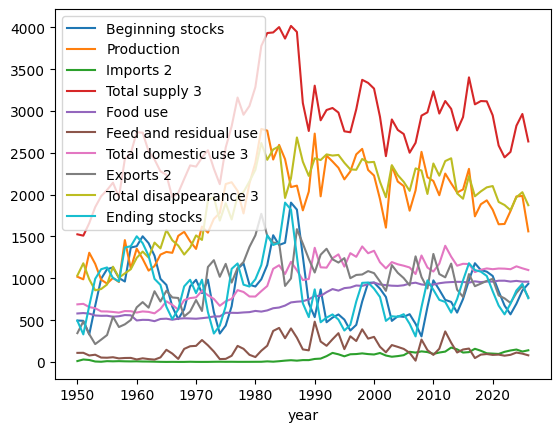

In [12]:
timeseries.set_index('year').sort_index().plot.line()


### Downloading to Local Pandas (Optional Handoff)

If you need to use local Python libraries that are not supported by BigFrames (such as custom plotting libraries or local ML frameworks), you can explicitly download the final transformed remote DataFrame into a standard local Pandas DataFrame using `.to_pandas()`:


In [13]:
pddf = timeseries.set_index('year').sort_index().to_pandas()
pddf


,Time period,Beginning stocks,Production,Imports 2,Total supply 3,Food use,Seed use,Feed and residual use,Total domestic use 3,Exports 2,Total disappearance 3,Ending stocks
year,,,,,,,,,,,,
1950-01-01 00:00:00+00:00,MY Jun-May,496.0,1019.0,11.0,1526.0,580.0,--,109.0,689.0,345.0,1034.0,492.0
1951-01-01 00:00:00+00:00,MY Jun-May,492.0,988.0,30.0,1510.0,585.0,--,110.0,695.0,485.0,1180.0,330.0
1952-01-01 00:00:00+00:00,MY Jun-May,330.0,1306.0,24.0,1660.0,578.0,--,78.0,656.0,332.0,988.0,672.0
1953-01-01 00:00:00+00:00,MY Jun-May,672.0,1173.0,6.0,1851.0,556.0,--,87.0,643.0,214.0,857.0,994.0
1954-01-01 00:00:00+00:00,MY Jun-May,994.0,984.0,3.0,1981.0,552.0,--,53.0,605.0,267.0,872.0,1109.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-01 00:00:00+00:00,MY Jun-May,674.431,1649.713,121.585,2445.729,971.677,68.369,75.503,1115.549,760.612,1876.161,569.568
2023-01-01 00:00:00+00:00,MY Jun-May,569.568,1803.942,137.798,2511.308,961.303,62.046,85.617,1108.966,705.908,1814.874,696.434
2024-01-01 00:00:00+00:00,MY Jun-May,696.434,1978.697,148.954,2824.085,969.493,61.1,112.863,1143.456,825.895,1969.351,854.734


## Conclusion: The Power of Hybrid Chaining

By leveraging BigQuery DataFrames and the `%%bqsql` magic, you have built a powerful, interoperable pipeline that seamlessly transitions between SQL and Python.

This hybrid approach offers several key benefits:
- **Optimal Tool Selection**: Use SQL for what it does best (complex queries, window functions, regex extractions on large sets) and Python for what it does best (visualization, statistical analysis, ML, orchestrating workflow).
- **Improved Readability**: Instead of massive, unreadable SQL queries with dozens of CTEs, or long, complex Pandas method chains, you can split your pipeline into logical steps, alternating between SQL and Python.
- **Seamless Scaling**: The exact same `%%bqsql` code can scale from a tiny local Pandas DataFrame to billions of rows in a production BigQuery table. You only need to swap the initial local Pandas DataFrame with a BigQuery DataFrame reference.


## Next Steps

In addition to the `%%bqsql` cell magic, BigFrames also registers a **BigQuery Accessor** on standard Pandas DataFrames, allowing you to run SQL scalar functions directly on local pandas data. 

For example, you can call powerful Google Cloud community UDFs from [BigQuery Utils](https://github.com/GoogleCloudPlatform/bigquery-utils/tree/master/udfs#bigquery-udfs), [BigFunctions](https://unytics.io/bigfunctions/bigfunctions/#function-categories), or [CARTO Analytics Toolbox for BigQuery](https://docs.carto.com/data-and-analysis/analytics-toolbox-for-bigquery) using `df.bigquery.sql_scalar(...)`:


### Scaling Up: Advanced BigQuery Features

While the BigQuery sandbox offers a powerful environment to test these hybrid Python-SQL workflows for free, some advanced features like BigQuery Machine Learning (BQML) are restricted. By connecting a billing account to your Google Cloud project, you can unlock advanced capabilities such as `ML.FORECAST` (or the `AI.FORECAST` function) to predict time-series data using Google's state-of-the-art foundational models directly from your SQL/Python chain.

### Feedback & Community

The BigFrames team would love to hear your feedback on the hybrid Python-SQL experience:
*   **Email**: [bigframes-feedback@google.com](mailto:bigframes-feedback@google.com)
*   **Issues**: File bug reports or feature requests on the [open-source BigFrames repository](https://github.com/googleapis/google-cloud-python/issues).
*   **Updates**: To receive news and updates, subscribe to the [BigFrames email list](https://docs.google.com/forms/d/10EnDyYdYUW9HvelHYuBRC8L3GdGVl3rX0aroinbRZyc/edit?resourcekey=0-QUsnpzF91gm9hsp04rSA6Q).
